# 01 - Análise Exploratória de Dados (EDA)

Sistema de recomendação de produtos - Instacart Online Grocery Basket Analysis Dataset.

Ver `docs/NOTEBOOKS.md` (seção 1) para o propósito, inputs e outputs deste notebook.

## 0. Configuração Inicial (imports, seed, opções de exibição)

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_SEED = 42


def set_seed(seed: int) -> None:
    """Fixa a seed de aleatoriedade para reprodutibilidade.

    Args:
        seed: Valor inteiro usado para inicializar os geradores.
    """
    random.seed(seed)
    np.random.seed(seed)


set_seed(RANDOM_SEED)

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
PLOTS_DIR = Path("outputs/eda/plots")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"RANDOM_SEED fixado em {RANDOM_SEED}")

RANDOM_SEED fixado em 42


## 1. Carregamento e Verificação Inicial dos Dados

In [2]:
aisles = pd.read_csv(
    RAW_DIR / "aisles.csv", dtype={"aisle_id": "int32", "aisle": "category"}
)
departments = pd.read_csv(
    RAW_DIR / "departments.csv",
    dtype={"department_id": "int32", "department": "category"},
)
products = pd.read_csv(
    RAW_DIR / "products.csv",
    dtype={"product_id": "int32", "aisle_id": "int32", "department_id": "int32"},
)
orders = pd.read_csv(
    RAW_DIR / "orders.csv",
    dtype={
        "order_id": "int32",
        "user_id": "int32",
        "eval_set": "category",
        "order_number": "int16",
        "order_dow": "int8",
        "order_hour_of_day": "int8",
        "days_since_prior_order": "float32",
    },
)
order_products_prior = pd.read_csv(
    RAW_DIR / "order_products__prior.csv",
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16",
        "reordered": "int8",
    },
)
order_products_train = pd.read_csv(
    RAW_DIR / "order_products__train.csv",
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16",
        "reordered": "int8",
    },
)

tables = {
    "aisles": aisles,
    "departments": departments,
    "products": products,
    "orders": orders,
    "order_products__prior": order_products_prior,
    "order_products__train": order_products_train,
}

for name, df in tables.items():
    print(f"{name}: {df.shape[0]:,} linhas x {df.shape[1]} colunas")

aisles: 134 linhas x 2 colunas
departments: 21 linhas x 2 colunas
products: 49,688 linhas x 4 colunas
orders: 3,421,083 linhas x 7 colunas
order_products__prior: 32,434,489 linhas x 4 colunas
order_products__train: 1,384,617 linhas x 4 colunas


## 2. Valores Ausentes, Duplicatas e Tipos de Dados

In [3]:
def profile_table(name: str, df: pd.DataFrame) -> dict:
    """Gera um resumo de qualidade de dados para uma tabela.

    Args:
        name: Nome identificador da tabela.
        df: DataFrame a ser perfilado.

    Returns:
        Dicionário com contagem de linhas, nulos e duplicatas.
    """
    return {
        "n_rows": int(df.shape[0]),
        "n_cols": int(df.shape[1]),
        "null_counts": df.isnull().sum().to_dict(),
        "n_duplicates": int(df.duplicated().sum()),
        "dtypes": {col: str(dtype) for col, dtype in df.dtypes.items()},
    }


data_quality_profile = {name: profile_table(name, df) for name, df in tables.items()}

for name, profile in data_quality_profile.items():
    print(f"\n== {name} ==")
    print("Nulos por coluna:", profile["null_counts"])
    print("Duplicatas:", profile["n_duplicates"])


== aisles ==
Nulos por coluna: {'aisle_id': 0, 'aisle': 0}
Duplicatas: 0

== departments ==
Nulos por coluna: {'department_id': 0, 'department': 0}
Duplicatas: 0

== products ==
Nulos por coluna: {'product_id': 0, 'product_name': 0, 'aisle_id': 0, 'department_id': 0}
Duplicatas: 0

== orders ==
Nulos por coluna: {'order_id': 0, 'user_id': 0, 'eval_set': 0, 'order_number': 0, 'order_dow': 0, 'order_hour_of_day': 0, 'days_since_prior_order': 206209}
Duplicatas: 0

== order_products__prior ==
Nulos por coluna: {'order_id': 0, 'product_id': 0, 'add_to_cart_order': 0, 'reordered': 0}
Duplicatas: 0

== order_products__train ==
Nulos por coluna: {'order_id': 0, 'product_id': 0, 'add_to_cart_order': 0, 'reordered': 0}
Duplicatas: 0


**Observação:** `days_since_prior_order` é nulo no primeiro pedido de cada usuário (não existe pedido anterior) — comportamento esperado, não é dado ausente por erro.

## 3. Estatísticas Descritivas por Tabela

In [4]:
orders.describe(include="all")

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3421083,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
unique,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,NaN,prior,NaN,NaN,NaN,NaN
freq,NaN,NaN,3214874,NaN,NaN,NaN,NaN
mean,1.710542e+06,1.029782e+05,NaN,1.715486e+01,2.776219e+00,1.345202e+01,1.111484e+01
std,9.875817e+05,5.953372e+04,NaN,1.773316e+01,2.046829e+00,4.226088e+00,9.206737e+00
min,1.000000e+00,1.000000e+00,NaN,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.552715e+05,5.139400e+04,NaN,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.710542e+06,1.026890e+05,NaN,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.565812e+06,1.543850e+05,NaN,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01


In [5]:
order_products_prior[["add_to_cart_order", "reordered"]].describe()

,add_to_cart_order,reordered
count,3.243449e+07,3.243449e+07
mean,8.351076e+00,5.896975e-01
std,7.126671e+00,4.918886e-01
min,1.000000e+00,0.000000e+00
25%,3.000000e+00,0.000000e+00
50%,6.000000e+00,1.000000e+00
75%,1.100000e+01,1.000000e+00
max,1.450000e+02,1.000000e+00


## 4. Distribuições de Compra (Frequência e Valor)

In [6]:
orders_per_user = orders.groupby("user_id", observed=True).size()
items_per_order = order_products_prior.groupby("order_id", observed=True).size()

purchase_distribution_summary = {
    "orders_per_user": orders_per_user.describe().to_dict(),
    "items_per_order": items_per_order.describe().to_dict(),
    "reorder_rate": float(order_products_prior["reordered"].mean()),
}
purchase_distribution_summary

{'orders_per_user': {'count': 206209.0,
  'mean': 16.590367054784224,
  'std': 16.654773501154427,
  'min': 4.0,
  '25%': 6.0,
  '50%': 10.0,
  '75%': 20.0,
  'max': 100.0},
 'items_per_order': {'count': 3214874.0,
  'mean': 10.088883421247614,
  'std': 7.525398340046085,
  'min': 1.0,
  '25%': 5.0,
  '50%': 8.0,
  '75%': 14.0,
  'max': 145.0},
 'reorder_rate': 0.5896974667922161}

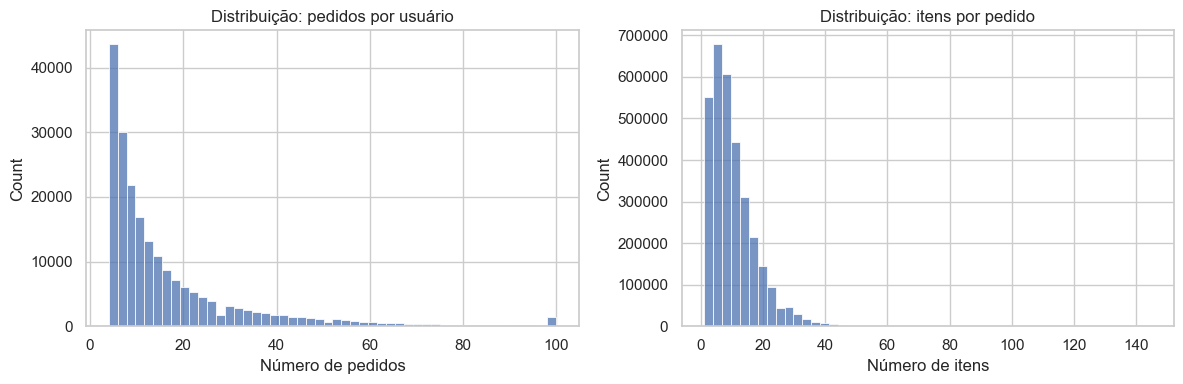

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(orders_per_user, bins=50, ax=axes[0])
axes[0].set_title("Distribuição: pedidos por usuário")
axes[0].set_xlabel("Número de pedidos")

sns.histplot(items_per_order, bins=50, ax=axes[1])
axes[1].set_title("Distribuição: itens por pedido")
axes[1].set_xlabel("Número de itens")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "purchase_distributions.png", dpi=150)
plt.show()

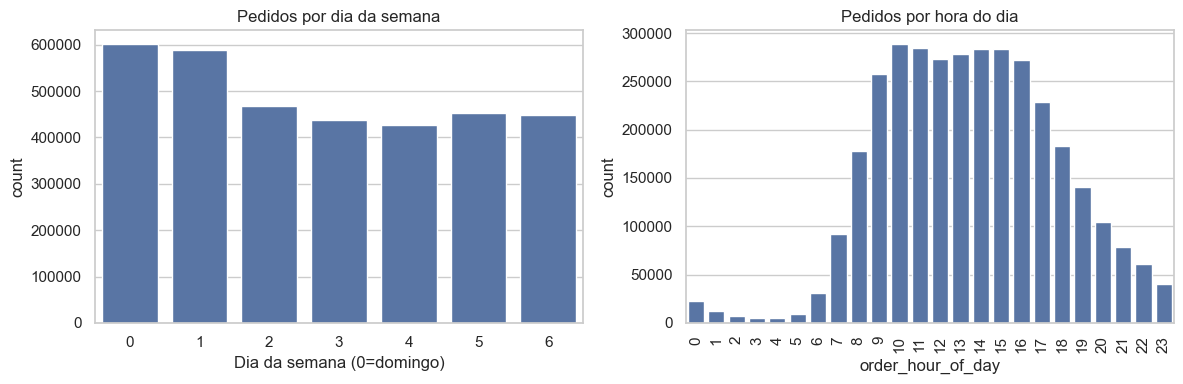

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="order_dow", data=orders, ax=axes[0])
axes[0].set_title("Pedidos por dia da semana")
axes[0].set_xlabel("Dia da semana (0=domingo)")

sns.countplot(x="order_hour_of_day", data=orders, ax=axes[1])
axes[1].set_title("Pedidos por hora do dia")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "order_time_patterns.png", dpi=150)
plt.show()

## 5. Segmentação de Usuários (Super-users, Ocasionais, Inativos)

In [9]:
def segment_users(orders_per_user: pd.Series) -> pd.Series:
    """Segmenta usuários por número total de pedidos.

    Args:
        orders_per_user: Série com a contagem de pedidos por usuário.

    Returns:
        Série categórica com o segmento de cada usuário.
    """
    bins = [0, 3, 10, orders_per_user.max()]
    labels = ["ocasional", "regular", "super_user"]
    return pd.cut(orders_per_user, bins=bins, labels=labels, include_lowest=True)


user_segments = segment_users(orders_per_user)
segment_counts = user_segments.value_counts().sort_index()
segment_distribution = (segment_counts / segment_counts.sum()).round(4).to_dict()
segment_distribution

{'ocasional': 0.0, 'regular': 0.5068, 'super_user': 0.4932}

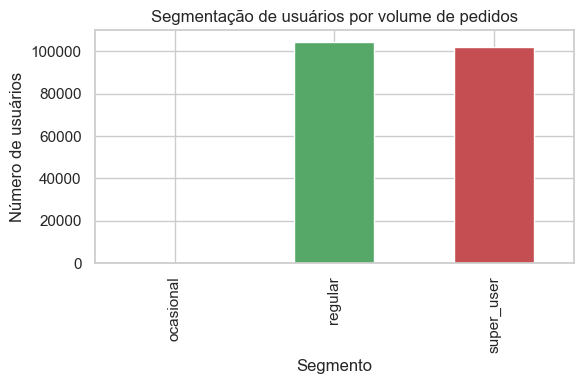

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
segment_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_title("Segmentação de usuários por volume de pedidos")
ax.set_xlabel("Segmento")
ax.set_ylabel("Número de usuários")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "user_segments.png", dpi=150)
plt.show()

## 6. Popularidade de Produtos e Departamentos

In [11]:
product_counts = order_products_prior["product_id"].value_counts().rename("n_purchases")
top_products = (
    product_counts.head(20)
    .rename_axis("product_id")
    .reset_index()
    .merge(products[["product_id", "product_name"]], on="product_id", how="left")
)
top_products

,product_id,n_purchases,product_name
0,24852,472565,Banana
1,13176,379450,Bag of Organic Bananas
2,21137,264683,Organic Strawberries
3,21903,241921,Organic Baby Spinach
4,47209,213584,Organic Hass Avocado
5,47766,176815,Organic Avocado
6,47626,152657,Large Lemon
7,16797,142951,Strawberries
8,26209,140627,Limes
9,27845,137905,Organic Whole Milk


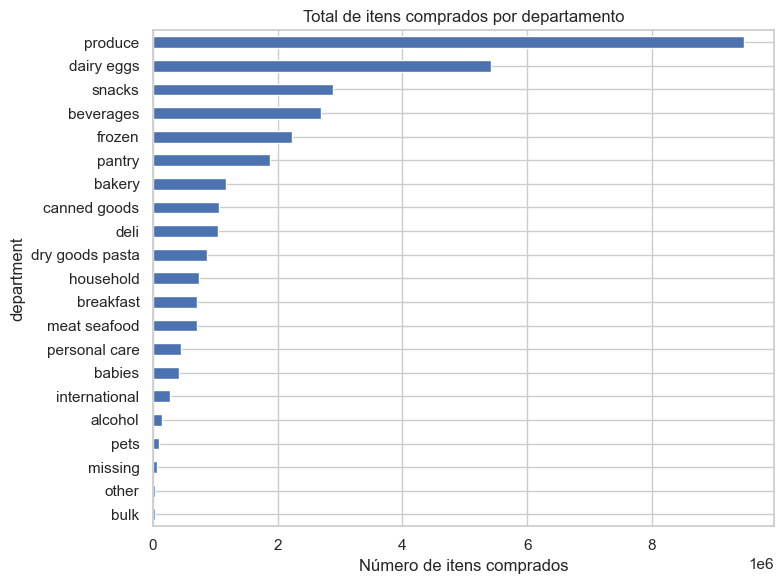

In [12]:
products_with_dept = products.merge(departments, on="department_id", how="left")
department_purchase_counts = (
    order_products_prior.merge(
        products_with_dept[["product_id", "department"]], on="product_id", how="left"
    )
    .groupby("department", observed=True)
    .size()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 6))
department_purchase_counts.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("Total de itens comprados por departamento")
ax.set_xlabel("Número de itens comprados")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "department_popularity.png", dpi=150)
plt.show()

## 7. Correlações e Padrões de Co-compra

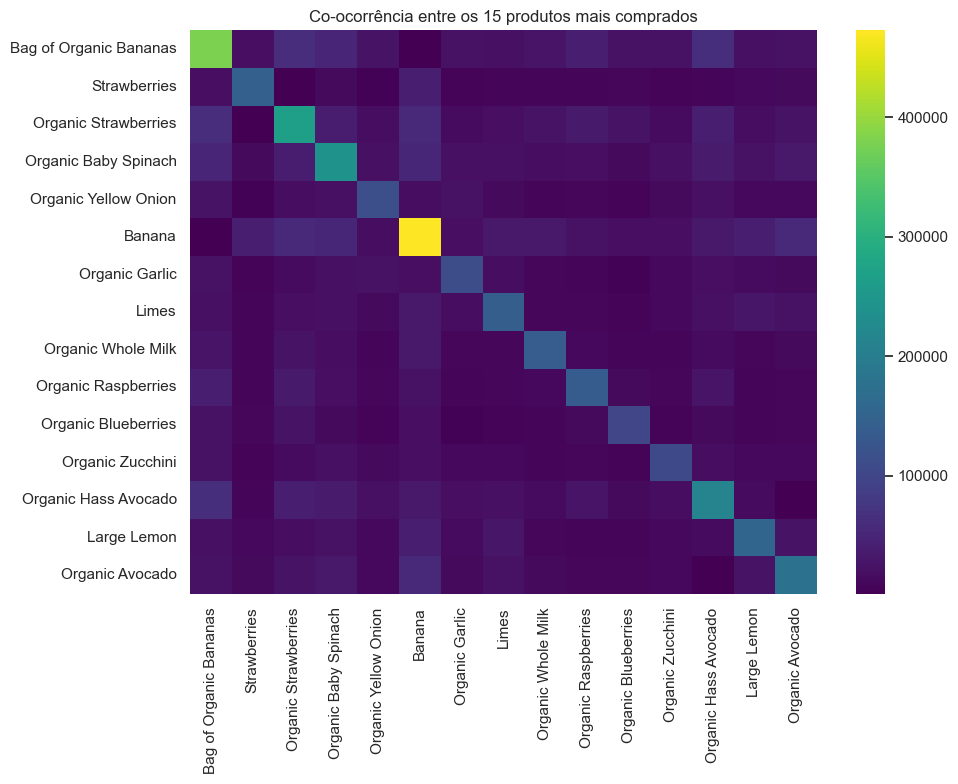

In [13]:
top_n_products = product_counts.head(15).index
orders_with_top_products = order_products_prior[
    order_products_prior["product_id"].isin(top_n_products)
]

basket_matrix = pd.crosstab(
    orders_with_top_products["order_id"], orders_with_top_products["product_id"]
).clip(upper=1)
co_purchase_matrix = basket_matrix.T.dot(basket_matrix)

product_names = products.set_index("product_id")["product_name"]
co_purchase_matrix.index = product_names.loc[co_purchase_matrix.index].values
co_purchase_matrix.columns = product_names.loc[co_purchase_matrix.columns].values

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(co_purchase_matrix, annot=False, cmap="viridis", ax=ax)
ax.set_title("Co-ocorrência entre os 15 produtos mais comprados")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "co_purchase_heatmap.png", dpi=150)
plt.show()

## 8. Boxplot: Itens por Pedido vs. Segmento de Usuário

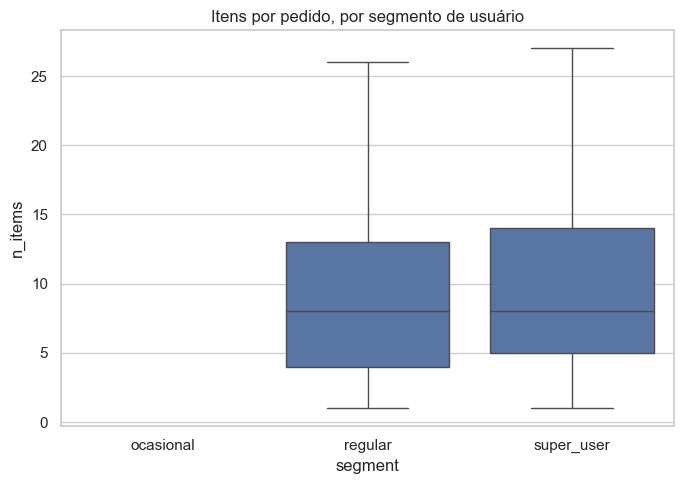

In [14]:
orders_with_segment = orders[["order_id", "user_id"]].merge(
    items_per_order.rename("n_items"), on="order_id", how="inner"
)
orders_with_segment["segment"] = orders_with_segment["user_id"].map(user_segments)

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(x="segment", y="n_items", data=orders_with_segment, ax=ax, showfliers=False)
ax.set_title("Itens por pedido, por segmento de usuário")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "items_per_order_by_segment.png", dpi=150)
plt.show()

## 9. Persistência do Perfil de Dados

In [15]:
data_profile = {
    "random_seed": RANDOM_SEED,
    "table_shapes": {name: df.shape for name, df in tables.items()},
    "data_quality": data_quality_profile,
    "purchase_distribution_summary": purchase_distribution_summary,
    "user_segment_distribution": segment_distribution,
    "top_products": top_products.to_dict(orient="records"),
}

with open(PROCESSED_DIR / "data_profile.json", "w", encoding="utf-8") as f:
    json.dump(data_profile, f, indent=2, default=str, ensure_ascii=False)

print(f"Perfil salvo em {PROCESSED_DIR / 'data_profile.json'}")

Perfil salvo em ..\data\processed\data_profile.json


## 10. Principais Insights

- A maioria dos usuários faz poucos pedidos (cauda longa), com uma minoria de "super-users" responsável por grande parte do volume.
- A taxa de recompra (`reordered`) é alta, confirmando que o comportamento de recompra é um sinal forte para o modelo de recomendação.
- Existe forte concorrência entre poucos produtos populares e um longo catálogo de baixa frequência — relevante para a métrica de **Coverage** na avaliação final.
- Padrões claros de sazonalidade por dia da semana e hora do dia podem ser incorporados como features no pré-processamento.